# Description - To run within SCC
# Creates results using Dense Model
# Currently, the file is created targeting the model saved in the path below
# restricted/projectnb/movelab/bcha/IMUforKnee/trainedModel/Dense_1st_torch/IWALQQ_AE_4th/

In [84]:
import torch
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import os
from os.path import join
from pickle import load
import pandas as pd
from natsort import natsorted
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Add the path to access helper modules (Windows path)
import sys
sys.path.append(r'R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\sensorwise')

# Import custom libraries
from dir_CBD import *
from plot_CBD import *
from scaler_CBD import *


In [85]:
# ==============================================================================
# LOAD TRAINING AND TEST DATA FOR NAIVE BASELINE ANALYSIS
# ==============================================================================
import numpy as np
import pandas as pd
import os
from os.path import join

def load_train_data_for_baseline(motherDir, modelVersion, nameDataset, dataType, num_folds=5):
    """
    Load all TRAINING data from Excel files to create consolidated arrays for baseline analysis
    """
    all_true_X = []
    all_true_Y = []
    all_true_Z = []
    
    print("Loading TRAINING data for baseline analysis...")
    
    for fold in range(num_folds):
        # KEY: Load from _train directories
        fold_dir = join(motherDir, modelVersion, nameDataset, dataType, f"{fold}_fold_train")
        
        if not os.path.exists(fold_dir):
            print(f"❌ Training fold directory not found: {fold_dir}")
            continue
            
        print(f"Processing training fold {fold}...")
        
        # Get all Excel files in this fold
        excel_files = [f for f in os.listdir(fold_dir) if f.endswith('.xlsx')]
        excel_files.sort(key=lambda x: int(x.split('.')[0]))  # Sort by dataIndex
        
        fold_true_X = []
        fold_true_Y = []
        fold_true_Z = []
        
        for excel_file in excel_files:
            file_path = join(fold_dir, excel_file)
            
            try:
                df = pd.read_excel(file_path, index_col=0)
                
                # Extract true values
                true_X_trial = df['X_True'].values  # Shape: (101,)
                true_Y_trial = df['Y_True'].values  # Shape: (101,)
                true_Z_trial = df['Z_True'].values  # Shape: (101,)
                
                fold_true_X.append(true_X_trial)
                fold_true_Y.append(true_Y_trial)
                fold_true_Z.append(true_Z_trial)
                
            except Exception as e:
                print(f"❌ Error loading training file {excel_file}: {e}")
                continue
        
        if fold_true_X:  # If we loaded any files from this fold
            all_true_X.extend(fold_true_X)
            all_true_Y.extend(fold_true_Y)
            all_true_Z.extend(fold_true_Z)
            print(f"  ✅ Loaded {len(fold_true_X)} training trials from fold {fold}")
    
    # Convert to numpy arrays
    train_X = np.array(all_true_X)  # Shape: (total_trials, 101)
    train_Y = np.array(all_true_Y)  # Shape: (total_trials, 101)
    train_Z = np.array(all_true_Z)  # Shape: (total_trials, 101)
    
    print(f"\n✅ Training data loading complete!")
    print(f"Training shapes:")
    print(f"  train_X: {train_X.shape}")
    print(f"  train_Y: {train_Y.shape}")
    print(f"  train_Z: {train_Z.shape}")
    print(f"Total training trials: {train_X.shape[0]}")
    
    return train_X, train_Y, train_Z

def load_test_data_for_baseline(motherDir, modelVersion, nameDataset, dataType, num_folds=5):
    """
    Load all TEST data from Excel files to create consolidated arrays for baseline analysis
    """
    all_true_X = []
    all_true_Y = []
    all_true_Z = []
    
    print("\nLoading TEST data for baseline analysis...")
    
    for fold in range(num_folds):
        # Load from regular fold directories (test data)
        fold_dir = join(motherDir, modelVersion, nameDataset, dataType, f"{fold}_fold")
        
        if not os.path.exists(fold_dir):
            print(f"❌ Test fold directory not found: {fold_dir}")
            continue
            
        print(f"Processing test fold {fold}...")
        
        # Get all Excel files in this fold
        excel_files = [f for f in os.listdir(fold_dir) if f.endswith('.xlsx')]
        excel_files.sort(key=lambda x: int(x.split('.')[0]))  # Sort by dataIndex
        
        fold_true_X = []
        fold_true_Y = []
        fold_true_Z = []
        
        for excel_file in excel_files:
            file_path = join(fold_dir, excel_file)
            
            try:
                df = pd.read_excel(file_path, index_col=0)
                
                # Extract true values
                true_X_trial = df['X_True'].values  # Shape: (101,)
                true_Y_trial = df['Y_True'].values  # Shape: (101,)
                true_Z_trial = df['Z_True'].values  # Shape: (101,)
                
                fold_true_X.append(true_X_trial)
                fold_true_Y.append(true_Y_trial)
                fold_true_Z.append(true_Z_trial)
                
            except Exception as e:
                print(f"❌ Error loading test file {excel_file}: {e}")
                continue
        
        if fold_true_X:  # If we loaded any files from this fold
            all_true_X.extend(fold_true_X)
            all_true_Y.extend(fold_true_Y)
            all_true_Z.extend(fold_true_Z)
            print(f"  ✅ Loaded {len(fold_true_X)} test trials from fold {fold}")
    
    # Convert to numpy arrays
    test_X = np.array(all_true_X)  # Shape: (total_trials, 101)
    test_Y = np.array(all_true_Y)  # Shape: (total_trials, 101)
    test_Z = np.array(all_true_Z)  # Shape: (total_trials, 101)
    
    print(f"\n✅ Test data loading complete!")
    print(f"Test shapes:")
    print(f"  test_X: {test_X.shape}")
    print(f"  test_Y: {test_Y.shape}")
    print(f"  test_Z: {test_Z.shape}")
    print(f"Total test trials: {test_X.shape[0]}")
    
    return test_X, test_Y, test_Z

# ==============================================================================
# LOAD YOUR DATA
# ==============================================================================
# Your actual configuration
motherDir = 'DenseModel'
modelVersion = 'MultiScaleCNN_optuna'
nameDataset = 'IWALQQ_1st_correction'
dataType = 'angle'

print("="*80)
print("LOADING TRAINING AND TEST DATA FOR BASELINE ANALYSIS")
print("="*80)
print(f"Looking for data in: {join(motherDir, modelVersion, nameDataset, dataType)}")

# Load training data
print("\n" + "="*50)
print("STEP 1: LOADING TRAINING DATA")
print("="*50)
train_X, train_Y, train_Z = load_train_data_for_baseline(
    motherDir=motherDir,
    modelVersion=modelVersion,
    nameDataset=nameDataset, 
    dataType=dataType,
    num_folds=5
)

# Load test data
print("\n" + "="*50)
print("STEP 2: LOADING TEST DATA")
print("="*50)
test_X, test_Y, test_Z = load_test_data_for_baseline(
    motherDir=motherDir,
    modelVersion=modelVersion,
    nameDataset=nameDataset, 
    dataType=dataType,
    num_folds=5
)

print("\n" + "="*80)
print("✅ ALL DATA READY FOR BASELINE ANALYSIS!")
print("="*80)
print("Data summary:")
print(f"  Training trials: {train_X.shape[0]}")
print(f"  Test trials: {test_X.shape[0]}")
print(f"  Time points per axis: {train_X.shape[1]}")
print("\nYou can now run:")
print("naive_results = naive_baseline_evaluate(")
print("    train_X, train_Y, train_Z,")
print("    test_X, test_Y, test_Z")
print(")")
print("="*80)

LOADING TRAINING AND TEST DATA FOR BASELINE ANALYSIS
Looking for data in: DenseModel\MultiScaleCNN_optuna\IWALQQ_1st_correction\angle

STEP 1: LOADING TRAINING DATA
Loading TRAINING data for baseline analysis...
Processing training fold 0...


KeyboardInterrupt: 

In [ ]:
import numpy as np

def naive_baseline_evaluate(
    train_X, train_Y, train_Z,
    test_X, test_Y, test_Z,
    timepoints_per_axis=101,
    drop_nan_trials=True,
    eps=1e-8
):
    """
    Evaluate a population-mean (training mean) baseline on test data.
    
    Parameters
    ----------
    train_X, train_Y, train_Z : ndarray (n_train_trials, T) or (n_train_trials, 3*T concatenated)
        Training true trajectories per axis (or concatenated 303). Used ONLY to form mean + range.
    test_X, test_Y, test_Z : ndarray
        Test true trajectories per axis (or concatenated form).
    timepoints_per_axis : int
        Number of time samples per axis (default 101).
    drop_nan_trials : bool
        If True, any trial with a NaN in that axis is excluded from BOTH per-trial and global metrics.
    eps : float
        Small constant to guard against zero ranges.
        
    Returns
    -------
    results : dict
        Per-axis metrics plus overall summary.
        Includes per-axis:
          - training_range
          - global_corr
          - global_rmse_deg
          - global_nrmse_pct  (percent of training range)
          - per_trial_corr_mean, per_trial_corr_std
          - per_trial_nrmse_mean_pct, per_trial_nrmse_std_pct
          - per_trial_rmse_deg (array)
          - n_trials_used, n_trials_dropped
    """
    
    axis_labels = ['X', 'Y', 'Z']
    train_arrays = [train_X, train_Y, train_Z]
    test_arrays  = [test_X, test_Y, test_Z]
    
    def _maybe_slice(A, axis_index):
        # Handle concatenated (n, 3*T) form if present
        if A.shape[1] == 3 * timepoints_per_axis:
            sl = slice(axis_index * timepoints_per_axis, (axis_index + 1) * timepoints_per_axis)
            return A[:, sl]
        return A
    
    results = {}
    print("="*80)
    print("NAIVE BASELINE ANALYSIS (Training-Mean Baseline on Test Set)")
    print("="*80)
    
    for i, ax in enumerate(axis_labels):
        train_axis = _maybe_slice(train_arrays[i], i)
        test_axis  = _maybe_slice(test_arrays[i],  i)
        
        # Training mean waveform & range (range defines normalization)
        train_mean_waveform = np.nanmean(train_axis, axis=0)
        train_min = np.nanmin(train_axis)
        train_max = np.nanmax(train_axis)
        train_range = max(train_max - train_min, eps)
        
        # Baseline prediction for every *test* trial = training mean waveform
        baseline_preds = np.tile(train_mean_waveform, (test_axis.shape[0], 1))
        
        # Identify valid test trials (no NaNs) if dropping
        if drop_nan_trials:
            valid_mask = ~np.isnan(test_axis).any(axis=1)
        else:
            valid_mask = np.ones(test_axis.shape[0], dtype=bool)
        
        test_axis_valid = test_axis[valid_mask]
        baseline_valid  = baseline_preds[valid_mask]
        n_dropped = int((~valid_mask).sum())
        
        # Per-trial metrics
        per_trial_corrs = []
        per_trial_rmses = []
        for t_true, t_pred in zip(test_axis_valid, baseline_valid):
            # (Optional) guard if any remaining NaNs
            if np.isnan(t_true).any() or np.isnan(t_pred).any():
                continue
            per_trial_corrs.append(np.corrcoef(t_true, t_pred)[0, 1])
            per_trial_rmses.append(np.sqrt(np.mean((t_pred - t_true)**2)))
        per_trial_corrs = np.array(per_trial_corrs)
        per_trial_rmses = np.array(per_trial_rmses)
        
        per_trial_nrmse_pct = 100 * per_trial_rmses / train_range
        
        # Global metrics (aggregate all valid test points)
        flat_true = test_axis_valid.reshape(-1)
        flat_pred = baseline_valid.reshape(-1)
        # Mask any NaN positions just in case
        m = ~np.isnan(flat_true) & ~np.isnan(flat_pred)
        flat_true = flat_true[m]
        flat_pred = flat_pred[m]
        
        global_rmse = np.sqrt(np.mean((flat_pred - flat_true)**2))
        global_corr = np.corrcoef(flat_true, flat_pred)[0, 1] if flat_true.size > 1 else np.nan
        global_nrmse_pct = 100 * global_rmse / train_range
        
        # SD ratio is identically 0 for baseline (all predictions identical across trials)
        # We still compute a check (mean predicted SD / mean true SD) to assert closeness
        true_sd_time = np.nanstd(test_axis_valid, axis=0)
        pred_sd_time = np.nanstd(baseline_valid, axis=0)  # should be zeros
        # Avoid division by zero; only consider time points with nonzero true SD
        nz_mask = true_sd_time > 0
        if nz_mask.any():
            sd_ratio_check = np.mean(pred_sd_time[nz_mask] / true_sd_time[nz_mask])
        else:
            sd_ratio_check = 0.0
        
        print(f"\nAxis {ax}")
        print(f"  Training range: {train_range:.2f}° (min {train_min:.2f}°, max {train_max:.2f}°)")
        print(f"  SD Ratio (should be 0): {sd_ratio_check:.3f}")
        print(f"  Global Corr: {global_corr:.3f}")
        print(f"  Global RMSE: {global_rmse:.3f}°  |  Global nRMSE: {global_nrmse_pct:.2f}% (of training range)")
        print(f"  Mean per-trial Corr: {per_trial_corrs.mean():.3f} ± {per_trial_corrs.std():.3f}")
        print(f"  Mean per-trial nRMSE: {per_trial_nrmse_pct.mean():.2f}% ± {per_trial_nrmse_pct.std():.2f}%")
        if n_dropped > 0:
            print(f"  Dropped {n_dropped} test trials containing NaNs")
        
        results[ax] = {
            "training_range": train_range,
            "training_min": train_min,
            "training_max": train_max,
            "global_corr": global_corr,
            "global_rmse_deg": global_rmse,
            "global_nrmse_pct": global_nrmse_pct,
            "per_trial_corr_mean": per_trial_corrs.mean(),
            "per_trial_corr_std": per_trial_corrs.std(),
            "per_trial_rmse_deg": per_trial_rmses,
            "per_trial_nrmse_pct": per_trial_nrmse_pct,
            "n_trials_used": int(valid_mask.sum()),
            "n_trials_dropped": n_dropped,
            "sd_ratio_check": sd_ratio_check
        }
    
    # Overall summary
    avg_global_corr = np.mean([results[a]["global_corr"] for a in axis_labels])
    avg_global_nrmse = np.mean([results[a]["global_nrmse_pct"] for a in axis_labels])
    print("\n" + "="*80)
    print("NAIVE BASELINE SUMMARY")
    print("="*80)
    print(f"Average global correlation: {avg_global_corr:.3f}")
    print(f"Average global nRMSE (% of training range): {avg_global_nrmse:.2f}%")
    print("Notes:")
    print("  • SD ratio is ~0 because the baseline predicts the same waveform for every trial.")
    print("  • Use per_trial_rmse_deg arrays later to compute ΔRMSE (baseline − model) per trial.")
    print("  • Compare model metrics against these to establish added value.")
    
    return results


    
# Step 2: Run your naive baseline analysis (your original code)
naive_results = naive_baseline_evaluate(
    train_X, train_Y, train_Z,  # You need training data too!
    test_X, test_Y, test_Z
)

In [ ]:
motherDir = 'DenseModel'
######### Configuration Section ########
exp_name = 'date_MultiScaleCNN_optuna'  # CNN experiment name
modelVersion = 'MultiScaleCNN_ensemble'  # CNN model version
nameDataset = 'IWALQQ_1st_correction'
dataType = 'angle'

# CNN Model location - Updated to match CNN training script output
CNN_OUTPUT_ROOT = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\MultiScaleCNN_ensemble"

MODEL_DIR = join(CNN_OUTPUT_ROOT, 'models')  # CNN models are directly in models folder

# Data location - Same as training script
dataDir = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Data\allnew_20220325_raw_byDeepak_csv\INC_ByStep\INC_ByZero\Included_checked\SAVE_dataSet"
DATA_DIR = join(dataDir, nameDataset)

# Fixed values
SEQ_LEN = 101
NUM_FEATURES = 42

# AI training settings
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("CNN MODEL_DIR:", MODEL_DIR)
print("DATA_DIR:", DATA_DIR)

# Quick check of available files
import os
if os.path.exists(MODEL_DIR):
    print("CNN Model files:")
    for file in sorted(os.listdir(MODEL_DIR)):
        print(f"  - {file}")
else:
    print(f" CNN model directory not found: {MODEL_DIR}")

In [ ]:
# CNN MODEL CLASSES - Required for CNN inference
import torch.nn as nn
import torch.nn.functional as F

class SafeBatchNorm1d(nn.Module):
    """BatchNorm1d that handles single-sample batches safely for Conv layers."""
    
    def __init__(self, num_features, **kwargs):
        super().__init__()
        self.bn = nn.BatchNorm1d(num_features, **kwargs)
    
    def forward(self, x):
        if self.training and x.size(0) == 1:
            # Skip batch norm for single sample during training
            return x
        return self.bn(x)

class MultiScaleCNN(nn.Module):
    """Configurable multi-branch 1D CNN with proper BatchNorm."""

    def __init__(self, kernels, channels, n_layers, pooling,
                 dropout_conv, dropout_fc, num_features=42, num_outputs=303):
        super().__init__()
        self.branches = nn.ModuleList()
        for k in kernels:
            layers = []
            in_ch = num_features
            for i in range(n_layers):
                out_ch = channels[min(i, len(channels) - 1)]
                layers.append(nn.Conv1d(in_ch, out_ch, kernel_size=k,
                                         padding=k // 2))
                layers.append(SafeBatchNorm1d(out_ch))
                layers.append(nn.ReLU())
                if dropout_conv > 0:
                    layers.append(nn.Dropout(dropout_conv))
                in_ch = out_ch
            if pooling == 'adaptive_avg':
                layers.append(nn.AdaptiveAvgPool1d(1))
            elif pooling == 'adaptive_max':
                layers.append(nn.AdaptiveMaxPool1d(1))
            else:  # global_avg over entire length
                layers.append(nn.AvgPool1d(kernel_size=101))
            self.branches.append(nn.Sequential(*layers))
        fc_in = channels[min(n_layers - 1, len(channels) - 1)] * len(kernels)
        self.fc = nn.Sequential(
            nn.Linear(fc_in, fc_in),
            nn.BatchNorm1d(fc_in),
            nn.ReLU(),
            nn.Dropout(dropout_fc),
            nn.Linear(fc_in, num_outputs),
        )

    def forward(self, x):  # x: (batch, 42, 101)
        outs = [branch(x).squeeze(-1) for branch in self.branches]
        x = torch.cat(outs, dim=1)
        return self.fc(x)

In [ ]:
from os.path import join
import os
import numpy as np
import pandas as pd
import torch
from pickle import load

# Assumptions:
# • MODELS_DIR, DATA_DIR, motherDir, modelVersion, nameDataset, dataType, ensure_dir are defined
# • MultiScaleCNN class is in scope

for numFold in range(5):
    # 1. Load ensemble checkpoint
    ensemble_path = join(MODEL_DIR, f'fold_{numFold}_ensemble_models.pt')
    if not os.path.exists(ensemble_path):
        print(f"Ensemble file not found: {ensemble_path}")
        continue

    ckpt = torch.load(ensemble_path, map_location='cpu')
    state_dicts     = ckpt['models']   # list of state_dicts
    ensemble_config = ckpt['config']   # your BEST_PARAMS dict
    print(f"Fold {numFold}: loaded ensemble with {len(state_dicts)} models")

    # 2. Extract only the CNN init args
    cnn_kwargs = {
        'kernels':      ensemble_config['kernels'],
        'channels':     ensemble_config['channels'],
        'n_layers':     ensemble_config['n_layers'],
        'pooling':      ensemble_config['pooling'],
        'dropout_conv': ensemble_config['dropout_conv'],
        'dropout_fc':   ensemble_config['dropout_fc'],
        # we’ll use the defaults for num_features=42 and num_outputs=303
    }

    # 3. Rebuild each ensemble member
    ensemble_models = []
    for sd in state_dicts:
        m = MultiScaleCNN(**cnn_kwargs)
        m.load_state_dict(sd)
        m.eval()
        ensemble_models.append(m)

    # 4. Load test data + scaler
    load_test    = np.load(join(DATA_DIR, f"{numFold}_fold_final_test.npz"))
    load_scaler4Y = load(open(join(DATA_DIR, f"{numFold}_fold_scaler4Y_{dataType}.pkl"), "rb"))
    n_samples    = load_test['final_X_test'].shape[0]
    print(f"Processing fold {numFold} with {n_samples} samples")

    # 5. Inference: average across the ensemble, then reshape/rescale/save
    for dataIndex in range(n_samples):
        X = load_test["final_X_test"][dataIndex].reshape(42, 101)[None, :]
        Y_true = load_test[f"final_Y_{dataType}_test"][dataIndex]

        with torch.no_grad():
            preds = []
            x_tensor = torch.from_numpy(X).float()
            for m in ensemble_models:
                preds.append(m(x_tensor).cpu().numpy())
            Y_pred = np.mean(np.stack(preds, axis=0), axis=0)

        # reshape to (101×3)
        Y_pred = Y_pred.reshape(3, -1).T
        Y_true = Y_true.reshape(3, -1).T

        # un‑scale
        Y_true_unscaled = (Y_true - load_scaler4Y.min_) / load_scaler4Y.scale_
        Y_pred_unscaled = (Y_pred - load_scaler4Y.min_) / load_scaler4Y.scale_

        # save to Excel
        df_true = pd.DataFrame(Y_true_unscaled, columns=['X_True','Y_True','Z_True'])
        df_pred = pd.DataFrame(Y_pred_unscaled, columns=['X_Pred','Y_Pred','Z_Pred'])
        df_save = pd.concat([df_true, df_pred], axis=1)

        out_dir = join(motherDir, modelVersion, nameDataset, dataType, f"{numFold}_fold")
        ensure_dir(out_dir)
        df_save.to_excel(join(out_dir, f"{dataIndex}.xlsx"))

    print(f"Fold {numFold} completed successfully!")

print("All CNN test folds completed!")



In [71]:
# import 필요한 라이브러리
import os
from os.path import join
from natsort import natsorted
from pathlib import Path
import shutil
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import plot_CBD

In [72]:
targetDir = join(motherDir,modelVersion,nameDataset,dataType)

In [73]:
# Main folder name to contain the results
targetDir = join(motherDir,modelVersion,nameDataset,dataType)
for axe in ["X","Y","Z"]:
    print("Axe : ", axe)
    globals()[f"true_{axe}"] = np.array([])
    globals()[f"pred_{axe}"] = np.array([])
    for fold in ["0_fold","1_fold","2_fold","3_fold","4_fold",]:
        print(f"now fold : ", fold)
        list_results = natsorted([_ for _ in os.listdir(join(targetDir,fold)) if _.endswith(".xlsx")])
        for result in list_results:
            singleResult = pd.read_excel(join(targetDir,fold,result))
            true = np.expand_dims(singleResult[f"{axe}_True"].to_numpy(), axis=0)
            pred = np.expand_dims(singleResult[f"{axe}_Pred"].to_numpy(), axis=0)
            
            # Better debug: Check the actual values
            if axe == "Y" and result == "0.xlsx":
                print(f"File: {fold}/{result}")
                print(f"Y_Pred from Excel: {singleResult['Y_Pred'].iloc[:5].values}")
                print(f"pred array: {pred[0, :5]}")
                print(f"pred has NaN: {np.isnan(pred).any()}")
                print(f"Excel Y_Pred has NaN: {singleResult['Y_Pred'].isna().any()}")
                break
            
            if len(globals()[f"true_{axe}"]) ==0:
                globals()[f"true_{axe}"] = true
                globals()[f"pred_{axe}"] = pred
            else:
                globals()[f"true_{axe}"] = np.concatenate((globals()[f"true_{axe}"], true),0)
                globals()[f"pred_{axe}"] = np.concatenate((globals()[f"pred_{axe}"], pred),0)

Axe :  X
now fold :  0_fold
now fold :  1_fold
now fold :  2_fold
now fold :  3_fold
now fold :  4_fold
Axe :  Y
now fold :  0_fold
File: 0_fold/0.xlsx
Y_Pred from Excel: [-0.84620396 -0.79760198 -0.82677874 -0.85363773 -0.32655914]
pred array: [-0.84620396 -0.79760198 -0.82677874 -0.85363773 -0.32655914]
pred has NaN: False
Excel Y_Pred has NaN: False
now fold :  1_fold
File: 1_fold/0.xlsx
Y_Pred from Excel: [-5.52875614 -6.09978872 -5.76603949 -5.13883035 -5.63183321]
pred array: [-5.52875614 -6.09978872 -5.76603949 -5.13883035 -5.63183321]
pred has NaN: False
Excel Y_Pred has NaN: False
now fold :  2_fold
File: 2_fold/0.xlsx
Y_Pred from Excel: [-3.12947196 -2.9343086  -3.35644877 -3.05356452 -3.12691148]
pred array: [-3.12947196 -2.9343086  -3.35644877 -3.05356452 -3.12691148]
pred has NaN: False
Excel Y_Pred has NaN: False
now fold :  3_fold
File: 3_fold/0.xlsx
Y_Pred from Excel: [-1.04847177 -1.26758619 -1.53349121 -2.25997749 -2.26591956]
pred array: [-1.04847177 -1.26758619 -1.5

In [74]:
def makeDataframe(file_Num):
    return pd.DataFrame(data=file_Num.transpose(),index = [idx for idx in range(len(file_Num[0]))],columns=[idx for idx in range(len(file_Num))])

In [75]:
# Rebuild arrays from the fixed Excel files
targetDir = join(motherDir,modelVersion,nameDataset,dataType)

true_X = np.array([])
pred_X = np.array([])
true_Y = np.array([])
pred_Y = np.array([])
true_Z = np.array([])
pred_Z = np.array([])

for fold in ["0_fold","1_fold","2_fold","3_fold","4_fold"]:
    list_results = natsorted([_ for _ in os.listdir(join(targetDir,fold)) if _.endswith(".xlsx")])
    for result in list_results:
        df = pd.read_excel(join(targetDir,fold,result))
        
        for axe in ["X","Y","Z"]:
            true_data = np.expand_dims(df[f"{axe}_True"].to_numpy(), axis=0)
            pred_data = np.expand_dims(df[f"{axe}_Pred"].to_numpy(), axis=0)
            
            if len(globals()[f"true_{axe}"]) == 0:
                globals()[f"true_{axe}"] = true_data
                globals()[f"pred_{axe}"] = pred_data
            else:
                globals()[f"true_{axe}"] = np.concatenate((globals()[f"true_{axe}"], true_data), 0)
                globals()[f"pred_{axe}"] = np.concatenate((globals()[f"pred_{axe}"], pred_data), 0)

print("Arrays rebuilt. Now run your Excel writer code.")

Arrays rebuilt. Now run your Excel writer code.


In [76]:
# Install xlsxwriter if not available
try:
    import xlsxwriter
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xlsxwriter"])
    import xlsxwriter
totalDir = join(motherDir,modelVersion,nameDataset,dataType)
writer = pd.ExcelWriter(join(totalDir,'TruePredDiff.xlsx'), engine='xlsxwriter')
for axe in ["X","Y","Z"]:
    for sess in ["true","pred"]:
        dataName = f"{sess}_{axe}"
        df = makeDataframe(globals()[dataName])
        df.to_excel(writer,sheet_name=str(dataName),index=False)
    df_diff = makeDataframe(abs(globals()[f"true_{axe}"]-globals()[f"pred_{axe}"]))
    df_diff.to_excel(writer,sheet_name=str(f"diff_{axe}"),index=False)
writer.close()  # Changed from save() to close()

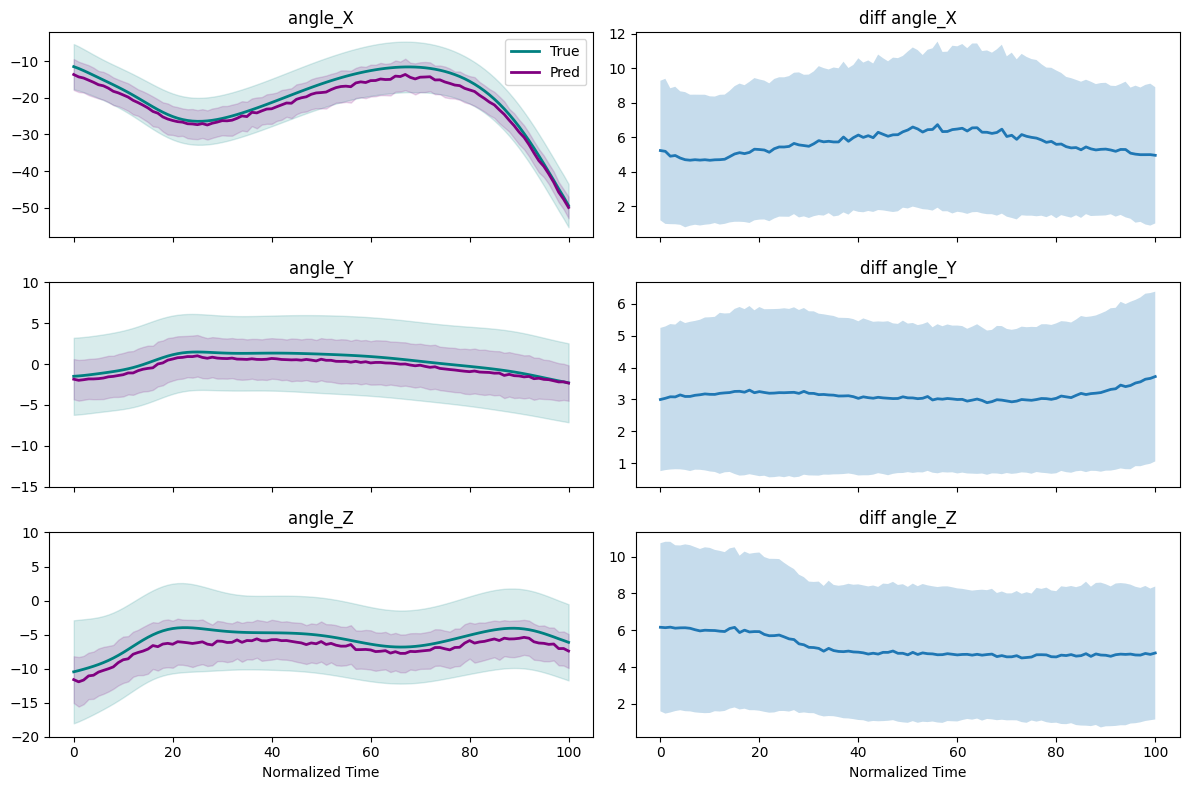

In [77]:
# === 3-row × 2-col summary:  True vs Pred  |  abs-diff ===
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np, matplotlib.pyplot as plt
pp  = PdfPages(join(targetDir, f"WHOLE_Total_result_{dataType}.pdf"))
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
time = np.linspace(0, 100, 101)
angle_labels = ['X', 'Y', 'Z']
for i, (T, P) in enumerate(zip([true_X, true_Y, true_Z],
                              [pred_X, pred_Y, pred_Z])):
   # --- if the matrices are still concatenated (n, 303) take the right slice
   if T.shape[1] == 303:
       sl = slice(i * 101, (i + 1) * 101)
       T, P = T[:, sl], P[:, sl]
   mT, sT = T.mean(0), T.std(0)
   mP, sP = P.mean(0), P.std(0)
   # -------- left column: True vs Pred --------
   ax = axes[i, 0]
   ax.plot(time, mT, lw=2, color='teal',   label='True')
   ax.plot(time, mP, lw=2, color='purple', label='Pred')
   ax.fill_between(time, mT - sT, mT + sT, alpha=0.15, color='teal')
   ax.fill_between(time, mP - sP, mP + sP, alpha=0.15, color='purple')
   ax.set_title(f'angle_{angle_labels[i]}')
   if i == 0:
       ax.legend()
   
   # Set custom y-axis limits for Y and Z to zoom out
   if i == 1:  # Y axis
       ax.set_ylim(-15, 10)
   elif i == 2:  # Z axis
       ax.set_ylim(-20, 10)
   
   # -------- right column: |True – Pred| --------
   diff      = np.abs(T - P)
   mD, sD    = diff.mean(0), diff.std(0)
   axd       = axes[i, 1]
   axd.plot(time, mD, lw=2)
   axd.fill_between(time, mD - sD, mD + sD, alpha=0.25)
   axd.set_title(f'diff angle_{angle_labels[i]}')

axes[-1, 0].set_xlabel('Normalized Time')
axes[-1, 1].set_xlabel('Normalized Time')
plt.tight_layout()
pp.savefig(fig)
pp.close()
plt.show()


In [78]:
"""
Test set evaluation using training-derived normalization ranges.
Computes per-trial and global metrics with proper trial filtering and variance (SD) calibration.
"""

import numpy as np
import pandas as pd
from dataclasses import dataclass, asdict

# ----------------------------- Configuration -------------------------------- #

AXES = ('X', 'Y', 'Z')
RANGE_EPS = 1e-8    # guard against zero range
PRINT_PER_AXIS = True

train_path = (r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\MultiScaleCNN_full_retrain\IWALQQ_1st_correction\angle\TruePredDiff_train.xlsx")

test_path = (r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\MultiScaleCNN_ensemble\IWALQQ_1st_correction\angle\TruePredDiff.xlsx")

# ----------------------------- Data Classes ---------------------------------- #

@dataclass
class AxisMetrics:
    axis: str
    training_range_deg: float
    training_min_deg: float
    training_max_deg: float
    global_rmse_deg: float
    global_nrmse_pct: float
    global_corr: float
    sd_ratio: float
    per_trial_corr_mean: float
    per_trial_corr_std: float
    per_trial_rmse_median_deg: float
    per_trial_rmse_iqr_deg: float
    per_trial_nrmse_mean_pct: float
    per_trial_nrmse_std_pct: float
    n_trials_total: int
    n_trials_used: int
    n_trials_dropped: int
    # Stored arrays (might be large; keep if you need downstream analyses)
    per_trial_corrs: np.ndarray
    per_trial_rmse_deg: np.ndarray
    per_trial_nrmse_pct: np.ndarray

# ----------------------------- Utility Functions ----------------------------- #

def load_axis_sheets(path, axis):
    """Load true & pred sheets for one axis (rows=time, cols=trials)."""
    t = pd.read_excel(path, sheet_name=f"true_{axis}", index_col=0)
    p = pd.read_excel(path, sheet_name=f"pred_{axis}", index_col=0)
    # Align columns defensively (should match already)
    common = [c for c in t.columns if c in p.columns]
    return t[common], p[common]

def compute_training_ranges(train_path, axes=AXES):
    """Compute global min/max & range per axis from training set true data."""
    ranges = {}
    print("Training data ranges (normalization denominators):")
    print("-"*70)
    for ax in axes:
        t, _ = load_axis_sheets(train_path, ax)
        vals = t.values
        gmin = np.nanmin(vals)
        gmax = np.nanmax(vals)
        rng = max(gmax - gmin, RANGE_EPS)
        ranges[ax] = dict(range=rng, min=gmin, max=gmax)
        print(f"{ax}: range={rng:.2f}° (min {gmin:.2f}°, max {gmax:.2f}°)")
    print("-"*70 + "\n")
    return ranges

def evaluate_axis(train_info, test_path, axis):
    """
    Evaluate model predictions for one axis on the *test* set using training range.
    Returns AxisMetrics.
    """
    training_range = train_info['range']
    t_min = train_info['min']
    t_max = train_info['max']

    true_df, pred_df = load_axis_sheets(test_path, axis)
    T = true_df.values
    P = pred_df.values

    # Identify & drop any trial with a NaN in true or pred
    invalid = np.isnan(T).any(axis=0) | np.isnan(P).any(axis=0)
    valid_mask = ~invalid
    T_valid = T[:, valid_mask]
    P_valid = P[:, valid_mask]

    n_total = T.shape[1]
    n_dropped = int(invalid.sum())
    n_used = int(valid_mask.sum())

    # Per-trial metrics
    per_trial_corrs = []
    per_trial_rmse = []
    for j in range(n_used):
        t_true = T_valid[:, j]
        t_pred = P_valid[:, j]
        # Correlation (guard zero variance)
        if np.std(t_true) > 0 and np.std(t_pred) > 0:
            c = np.corrcoef(t_true, t_pred)[0, 1]
        else:
            c = np.nan
        per_trial_corrs.append(c)
        per_trial_rmse.append(np.sqrt(np.mean((t_pred - t_true)**2)))

    per_trial_corrs = np.array(per_trial_corrs, dtype=float)
    per_trial_rmse = np.array(per_trial_rmse, dtype=float)

    # Remove NaN correlations for summary (e.g. flat signals)
    corr_clean = per_trial_corrs[~np.isnan(per_trial_corrs)]

    per_trial_nrmse_pct = 100.0 * per_trial_rmse / training_range

    # Global metrics using only valid trials
    flat_true = T_valid.reshape(-1)
    flat_pred = P_valid.reshape(-1)
    mask = ~np.isnan(flat_true) & ~np.isnan(flat_pred)
    flat_true = flat_true[mask]
    flat_pred = flat_pred[mask]

    global_rmse = np.sqrt(np.mean((flat_pred - flat_true)**2))
    if flat_true.size > 1 and np.std(flat_true) > 0 and np.std(flat_pred) > 0:
        global_corr = np.corrcoef(flat_true, flat_pred)[0, 1]
    else:
        global_corr = np.nan
    global_nrmse_pct = 100.0 * global_rmse / training_range

    # SD ratio (across-trial dispersion)
    true_sd_time = np.nanstd(T_valid, axis=1)
    pred_sd_time = np.nanstd(P_valid, axis=1)
    nz = true_sd_time > 0
    if nz.any():
        sd_ratio = np.mean(pred_sd_time[nz] / true_sd_time[nz])
    else:
        sd_ratio = np.nan

    # Robust summaries
    rmse_median = float(np.median(per_trial_rmse)) if per_trial_rmse.size else np.nan
    rmse_iqr = float(np.percentile(per_trial_rmse, 75) - np.percentile(per_trial_rmse, 25)) if per_trial_rmse.size else np.nan

    return AxisMetrics(
        axis=axis,
        training_range_deg=training_range,
        training_min_deg=t_min,
        training_max_deg=t_max,
        global_rmse_deg=global_rmse,
        global_nrmse_pct=global_nrmse_pct,
        global_corr=global_corr,
        sd_ratio=sd_ratio,
        per_trial_corr_mean=float(np.nanmean(corr_clean)) if corr_clean.size else np.nan,
        per_trial_corr_std=float(np.nanstd(corr_clean)) if corr_clean.size else np.nan,
        per_trial_rmse_median_deg=rmse_median,
        per_trial_rmse_iqr_deg=rmse_iqr,
        per_trial_nrmse_mean_pct=float(per_trial_nrmse_pct.mean()) if per_trial_nrmse_pct.size else np.nan,
        per_trial_nrmse_std_pct=float(per_trial_nrmse_pct.std()) if per_trial_nrmse_pct.size else np.nan,
        n_trials_total=n_total,
        n_trials_used=n_used,
        n_trials_dropped=n_dropped,
        per_trial_corrs=per_trial_corrs,
        per_trial_rmse_deg=per_trial_rmse,
        per_trial_nrmse_pct=per_trial_nrmse_pct
    )

def print_axis_table(metrics_list):
    """Pretty print per-axis summary."""
    print("="*95)
    print("TEST SET EVALUATION (normalized by training ranges)")
    print("="*95)
    header = ("Axis  "
              "Per-trial Corr (μ±σ)  "
              "GlobalCorr  "
              "GlobRMSE°  Glob nRMSE%  "
              "SD_ratio  "
              "Per-trial nRMSE μ±σ (%)  "
              "TrialsUsed/Total")
    print(header)
    print("-"*95)
    for m in metrics_list:
        print(f"{m.axis:<4} "
              f"{m.per_trial_corr_mean:>6.3f}±{m.per_trial_corr_std:>5.3f}  "
              f"{m.global_corr:>9.3f}  "
              f"{m.global_rmse_deg:>7.3f}   {m.global_nrmse_pct:>7.2f}   "
              f"{m.sd_ratio:>7.3f}  "
              f"{m.per_trial_nrmse_mean_pct:>6.2f}±{m.per_trial_nrmse_std_pct:>5.2f}   "
              f"{m.n_trials_used:>3}/{m.n_trials_total}")
    print("-"*95)
    # Macro averages (ignore NaNs)
    gm = [m.global_rmse_deg for m in metrics_list]
    gn = [m.global_nrmse_pct for m in metrics_list]
    gc = [m.global_corr for m in metrics_list]
    sr = [m.sd_ratio for m in metrics_list]
    macro_rmse = np.nanmean(gm)
    macro_nrmse = np.nanmean(gn)
    macro_corr = np.nanmean(gc)
    macro_sd_ratio = np.nanmean(sr)
    print(f"AVG   global_corr={macro_corr:.3f}  global_rmse={macro_rmse:.3f}°  "
          f"global_nRMSE={macro_nrmse:.2f}%  SD_ratio={macro_sd_ratio:.3f}")
    print("="*95)
    print("Notes:")
    print("  • SD_ratio <1 indicates under-dispersion (shrinkage); >1 over-dispersion; ≈1 well-calibrated variance.")
    print("  • global_nRMSE uses a *single* training min-max per axis; per-trial nRMSE is mean of each trial's RMSE / training range.")
    print("  • Use stored per_trial_rmse_deg arrays for ΔRMSE vs naive baseline.")
    print()

def main():
    # 1. Compute training ranges
    training_ranges = compute_training_ranges(train_path, AXES)

    # 2. Evaluate each axis on test
    metrics = []
    for ax in AXES:
        m = evaluate_axis(training_ranges[ax], test_path, ax)
        metrics.append(m)

    # 3. Print table
    print_axis_table(metrics)

    # 4. Optional: convert to DataFrame for saving
    records = []
    for m in metrics:
        rec = asdict(m).copy()
        # Remove large arrays if you want a compact CSV
        rec.pop('per_trial_corrs')
        rec.pop('per_trial_rmse_deg')
        rec.pop('per_trial_nrmse_pct')
        records.append(rec)
    df_summary = pd.DataFrame(records)
    # Example (uncomment to save):
    # df_summary.to_csv("test_metrics_summary.csv", index=False)

    return metrics, df_summary, training_ranges

if __name__ == "__main__":
    metrics, df_summary, training_ranges = main()


Training data ranges (normalization denominators):
----------------------------------------------------------------------
X: range=75.98° (min -67.41°, max 8.56°)
Y: range=27.80° (min -13.18°, max 14.61°)
Z: range=55.54° (min -41.26°, max 14.28°)
----------------------------------------------------------------------

TEST SET EVALUATION (normalized by training ranges)
Axis  Per-trial Corr (μ±σ)  GlobalCorr  GlobRMSE°  Glob nRMSE%  SD_ratio  Per-trial nRMSE μ±σ (%)  TrialsUsed/Total
-----------------------------------------------------------------------------------------------
X     0.942±0.054      0.751    7.083      9.32     0.616    8.18± 4.48   875/875
Y     0.581±0.290      0.598    3.972     14.29     0.543   12.22± 7.41   875/875
Z     0.457±0.326      0.224    6.391     11.51     0.499   10.10± 5.52   875/875
-----------------------------------------------------------------------------------------------
AVG   global_corr=0.525  global_rmse=5.815°  global_nRMSE=11.71%  SD_ratio=

# Same Analysis on Training Data


In [79]:
import os
from os.path import join
import numpy as np
import pandas as pd
import torch
from pickle import load

# Assumptions:
# • MODELS_DIR, DATA_DIR, motherDir, modelVersion, nameDataset, dataType, ensure_dir are already defined
# • MultiScaleCNN class is in scope

for numFold in range(5):
    # 1. Load ensemble checkpoint
    ensemble_path = join(MODEL_DIR, f'fold_{numFold}_ensemble_models.pt')
    if not os.path.exists(ensemble_path):
        print(f"Ensemble file not found: {ensemble_path}")
        continue

    ckpt = torch.load(ensemble_path, map_location='cpu')
    state_dicts     = ckpt['models']   # list of state_dicts
    ensemble_config = ckpt['config']   # BEST_PARAMS dict
    print(f"Fold {numFold}: loaded ensemble with {len(state_dicts)} models")

    # 2. Extract only the CNN init args
    cnn_kwargs = {
        'kernels':      ensemble_config['kernels'],
        'channels':     ensemble_config['channels'],
        'n_layers':     ensemble_config['n_layers'],
        'pooling':      ensemble_config['pooling'],
        'dropout_conv': ensemble_config['dropout_conv'],
        'dropout_fc':   ensemble_config['dropout_fc'],
        # defaults: num_features=42, num_outputs=303
    }

    # 3. Rebuild each ensemble member
    ensemble_models = []
    for sd in state_dicts:
        m = MultiScaleCNN(**cnn_kwargs)
        m.load_state_dict(sd)
        m.eval()
        ensemble_models.append(m)

    # 4. Load training data + scaler
    load_train     = np.load(join(DATA_DIR, f"{numFold}_fold_final_train.npz"))
    load_scaler4Y = load(open(join(DATA_DIR, f"{numFold}_fold_scaler4Y_{dataType}.pkl"), "rb"))
    n_samples      = load_train['final_X_train'].shape[0]
    print(f"Processing fold {numFold} with {n_samples} training samples")

    # 5. Inference: average across ensemble, then reshape/rescale/save
    for dataIndex in range(n_samples):
        X = load_train["final_X_train"][dataIndex].reshape(42, 101)[None, :]
        Y_true = load_train[f"final_Y_{dataType}_train"][dataIndex]

        with torch.no_grad():
            preds = []
            x_tensor = torch.from_numpy(X).float()
            for m in ensemble_models:
                preds.append(m(x_tensor).cpu().numpy())
            Y_pred = np.mean(np.stack(preds, axis=0), axis=0)

        # reshape to (101×3)
        Y_pred = Y_pred.reshape(3, -1).T
        Y_true = Y_true.reshape(3, -1).T

        # un-scale
        Y_true_unscaled = (Y_true - load_scaler4Y.min_) / load_scaler4Y.scale_
        Y_pred_unscaled = (Y_pred - load_scaler4Y.min_) / load_scaler4Y.scale_

        # save to Excel
        df_true = pd.DataFrame(Y_true_unscaled, columns=['X_True','Y_True','Z_True'])
        df_pred = pd.DataFrame(Y_pred_unscaled, columns=['X_Pred','Y_Pred','Z_Pred'])
        df_save = pd.concat([df_true, df_pred], axis=1)

        out_dir = join(motherDir, modelVersion, nameDataset, dataType, f"{numFold}_fold_train")
        ensure_dir(out_dir)
        df_save.to_excel(join(out_dir, f"{dataIndex}.xlsx"))

    print(f"Fold {numFold} training data completed successfully!")

print("All CNN training‐data folds completed successfully!")


Fold 0: loaded ensemble with 3 models


C:\Users\asmith8\AppData\Local\Temp\ipykernel_26932\688045674.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ensemble_path, map_location='cpu')


Processing fold 0 with 722 training samples
Fold 0 training data completed successfully!


C:\Users\asmith8\AppData\Local\Temp\ipykernel_26932\688045674.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ensemble_path, map_location='cpu')


Fold 1: loaded ensemble with 3 models
Processing fold 1 with 667 training samples
Fold 1 training data completed successfully!
Fold 2: loaded ensemble with 3 models


...

Processing fold 2 with 722 training samples
Fold 2 training data completed successfully!


C:\Users\asmith8\AppData\Local\Temp\ipykernel_26932\688045674.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ensemble_path, map_location='cpu')


Fold 3: loaded ensemble with 3 models
Processing fold 3 with 670 training samples
Fold 3 training data completed successfully!


C:\Users\asmith8\AppData\Local\Temp\ipykernel_26932\688045674.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ensemble_path, map_location='cpu')


Fold 4: loaded ensemble with 3 models
Processing fold 4 with 723 training samples
Fold 4 training data completed successfully!
All CNN training‐data folds completed successfully!


In [80]:
# Rebuild arrays from training Excel files
targetDir_train = join(motherDir,modelVersion,nameDataset,dataType)

true_train_X = np.array([])
pred_train_X = np.array([])
true_train_Y = np.array([])
pred_train_Y = np.array([])
true_train_Z = np.array([])
pred_train_Z = np.array([])

for fold in ["0_fold_train","1_fold_train","2_fold_train","3_fold_train","4_fold_train"]:
    list_results = natsorted([_ for _ in os.listdir(join(targetDir_train,fold)) if _.endswith(".xlsx")])
    for result in list_results:
        df = pd.read_excel(join(targetDir_train,fold,result))
        
        for axe in ["X","Y","Z"]:
            true_train_data = np.expand_dims(df[f"{axe}_True"].to_numpy(), axis=0)
            pred_train_data = np.expand_dims(df[f"{axe}_Pred"].to_numpy(), axis=0)
            
            if len(globals()[f"true_train_{axe}"]) == 0:
                globals()[f"true_train_{axe}"] = true_train_data
                globals()[f"pred_train_{axe}"] = pred_train_data
            else:
                globals()[f"true_train_{axe}"] = np.concatenate((globals()[f"true_train_{axe}"], true_train_data), 0)
                globals()[f"pred_train_{axe}"] = np.concatenate((globals()[f"pred_train_{axe}"], pred_train_data), 0)

print("Arrays rebuilt. Now run your Excel writer code.")

Arrays rebuilt. Now run your Excel writer code.


In [81]:
# Save training arrays to Excel - FIXED VERSION
try:
    import xlsxwriter
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xlsxwriter"])
    import xlsxwriter

totalDir = join(motherDir, modelVersion, nameDataset, dataType)
writer = pd.ExcelWriter(join(totalDir, 'TruePredDiff_train.xlsx'), engine='xlsxwriter')

for axe in ["X", "Y", "Z"]:
    for sess in ["true", "pred"]:
        # FIXED: Use the correct variable names with "_train"
        dataName = f"{sess}_train_{axe}"
        df = makeDataframe(globals()[dataName])
        # Save with simplified sheet names (without "_train")
        sheet_name = f"{sess}_{axe}"
        df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    # Calculate differences using the correct variable names
    df_diff = makeDataframe(abs(globals()[f"true_train_{axe}"] - globals()[f"pred_train_{axe}"]))
    df_diff.to_excel(writer, sheet_name=f"diff_{axe}", index=False)

writer.close()

print("Training data saved successfully!")
print("Sheets created:")
for axe in ["X", "Y", "Z"]:
    print(f"  - true_{axe}, pred_{axe}, diff_{axe}")

Training data saved successfully!
Sheets created:
  - true_X, pred_X, diff_X
  - true_Y, pred_Y, diff_Y
  - true_Z, pred_Z, diff_Z


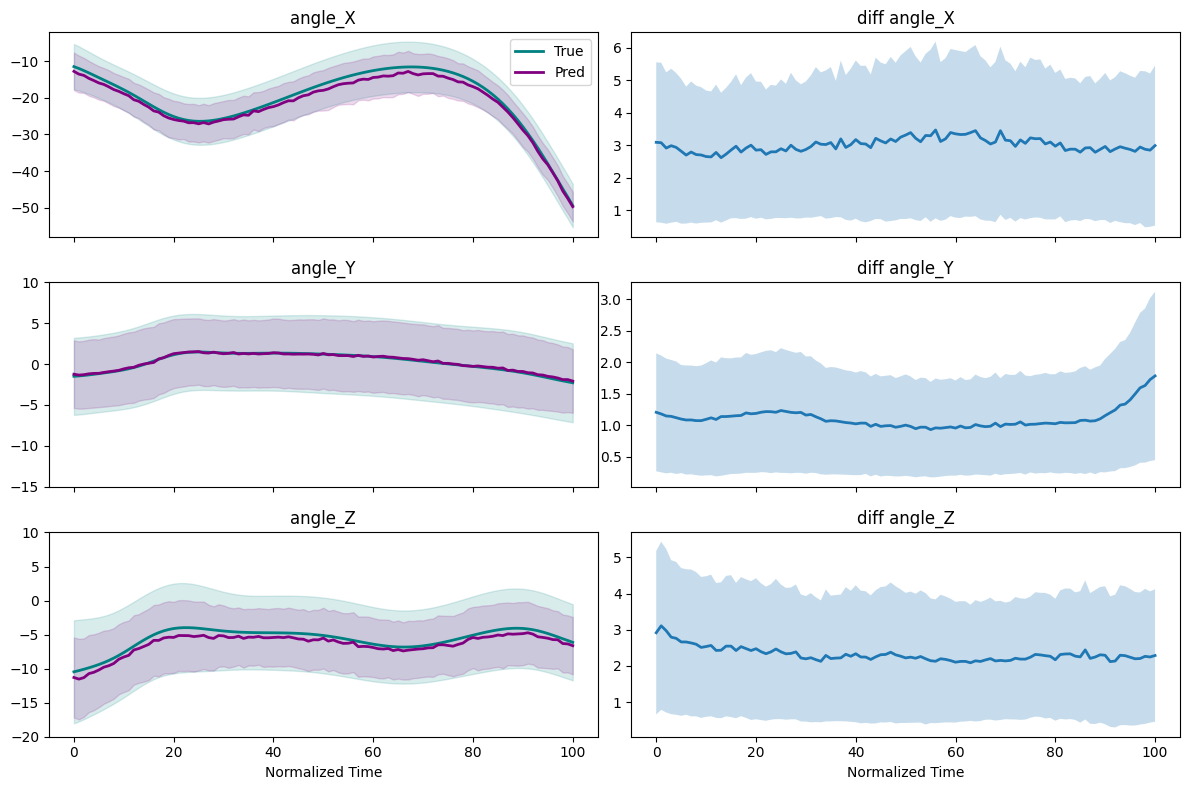

In [82]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np, matplotlib.pyplot as plt
pp  = PdfPages(join(targetDir, f"WHOLE_Total_result_train_{dataType}.pdf"))
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
time = np.linspace(0, 100, 101)
angle_labels = ['X', 'Y', 'Z']
for i, (T, P) in enumerate(zip([true_train_X, true_train_Y, true_train_Z],
                              [pred_train_X, pred_train_Y, pred_train_Z])):
   # --- if the matrices are still concatenated (n, 303) take the right slice
   if T.shape[1] == 303:
       sl = slice(i * 101, (i + 1) * 101)
       T, P = T[:, sl], P[:, sl]
   mT, sT = T.mean(0), T.std(0)
   mP, sP = P.mean(0), P.std(0)
   # -------- left column: True vs Pred --------
   ax = axes[i, 0]
   ax.plot(time, mT, lw=2, color='teal',   label='True')
   ax.plot(time, mP, lw=2, color='purple', label='Pred')
   ax.fill_between(time, mT - sT, mT + sT, alpha=0.15, color='teal')
   ax.fill_between(time, mP - sP, mP + sP, alpha=0.15, color='purple')
   ax.set_title(f'angle_{angle_labels[i]}')
   if i == 0:
       ax.legend()
   
   # Set custom y-axis limits for Y and Z to zoom out
   if i == 1:  # Y axis
       ax.set_ylim(-15, 10)
   elif i == 2:  # Z axis
       ax.set_ylim(-20, 10)
   
   # -------- right column: |True – Pred| --------
   diff      = np.abs(T - P)
   mD, sD    = diff.mean(0), diff.std(0)
   axd       = axes[i, 1]
   axd.plot(time, mD, lw=2)
   axd.fill_between(time, mD - sD, mD + sD, alpha=0.25)
   axd.set_title(f'diff angle_{angle_labels[i]}')

axes[-1, 0].set_xlabel('Normalized Time')
axes[-1, 1].set_xlabel('Normalized Time')
plt.tight_layout()
pp.savefig(fig)
pp.close()
plt.show()


In [83]:
import numpy as np
import pandas as pd

def evaluate_training_predictions(
    train_path,
    axes=('X','Y','Z'),
    timepoints_per_axis=101,
    range_eps=1e-8
):
    """
    Evaluate training-set performance (model predictions vs true) using
    fixed global training ranges per axis and consistent trial filtering.

    Assumes sheets: true_X, pred_X, true_Y, pred_Y, true_Z, pred_Z.
    Each sheet: rows = time points, columns = trials (as in your Excel dumps).
    """
    ranges = {}
    # First pass: load true sheets, compute range (min-max) per axis
    for ax in axes:
        T = pd.read_excel(train_path, sheet_name=f"true_{ax}", index_col=0)
        vals = T.values
        gmin = np.nanmin(vals)
        gmax = np.nanmax(vals)
        r = max(gmax - gmin, range_eps)
        ranges[ax] = dict(range=r, min=gmin, max=gmax)

    print("="*80)
    print("TRAINING SET EVALUATION (Global range normalization from training true data)")
    print("="*80)
    print("Training ranges:")
    for ax in axes:
        info = ranges[ax]
        print(f"  {ax}: {info['range']:.2f}° (min {info['min']:.2f}°, max {info['max']:.2f}°)")
    print("\n" + "-"*80)

    train_summary = {}

    header_printed = False
    rows_print = []

    for ax in axes:
        # Load true & pred
        T_df = pd.read_excel(train_path, sheet_name=f"true_{ax}", index_col=0)
        P_df = pd.read_excel(train_path, sheet_name=f"pred_{ax}", index_col=0)

        # Align columns (defensive)
        common_cols = [c for c in T_df.columns if c in P_df.columns]
        T = T_df[common_cols].values
        P = P_df[common_cols].values

        # Trials with any NaN in true or pred are dropped entirely
        trial_nan_mask = np.isnan(T).any(axis=0) | np.isnan(P).any(axis=0)
        valid_mask = ~trial_nan_mask

        T_valid = T[:, valid_mask]
        P_valid = P[:, valid_mask]

        n_total = T.shape[1]
        n_dropped = trial_nan_mask.sum()
        n_used = valid_mask.sum()

        # Per-trial metrics
        # (time, trials) -> transpose for trial-wise iteration
        per_trial_corrs = []
        per_trial_rmses = []
        for j in range(n_used):
            t_true = T_valid[:, j]
            t_pred = P_valid[:, j]
            # Corr
            c = np.corrcoef(t_true, t_pred)[0, 1] if np.std(t_true) > 0 and np.std(t_pred) > 0 else np.nan
            per_trial_corrs.append(c)
            # RMSE
            per_trial_rmses.append(np.sqrt(np.mean((t_pred - t_true)**2)))

        per_trial_corrs = np.array(per_trial_corrs, dtype=float)
        per_trial_rmses = np.array(per_trial_rmses, dtype=float)

        # Remove NaN correlations (flat signals)
        valid_corr_mask = ~np.isnan(per_trial_corrs)
        per_trial_corrs_clean = per_trial_corrs[valid_corr_mask]

        axis_range = ranges[ax]['range']
        per_trial_nrmse_pct = 100 * per_trial_rmses / axis_range

        # Global metrics (aggregate only valid trials)
        flat_true = T_valid.reshape(-1)
        flat_pred = P_valid.reshape(-1)
        m = ~np.isnan(flat_true) & ~np.isnan(flat_pred)
        flat_true = flat_true[m]
        flat_pred = flat_pred[m]

        global_rmse = np.sqrt(np.mean((flat_pred - flat_true)**2))
        if flat_true.size > 1 and np.std(flat_true) > 0 and np.std(flat_pred) > 0:
            global_corr = np.corrcoef(flat_true, flat_pred)[0, 1]
        else:
            global_corr = np.nan
        global_nrmse_pct = 100 * global_rmse / axis_range

        # SD ratio (across trials at each time point)
        true_sd_time = np.nanstd(T_valid, axis=1)
        pred_sd_time = np.nanstd(P_valid, axis=1)
        nz = true_sd_time > 0
        if nz.any():
            sd_ratio = np.mean(pred_sd_time[nz] / true_sd_time[nz])
        else:
            sd_ratio = np.nan

        # Summaries
        corr_mean = np.nanmean(per_trial_corrs_clean)
        corr_std  = np.nanstd(per_trial_corrs_clean)
        nrmse_mean = per_trial_nrmse_pct.mean()
        nrmse_std  = per_trial_nrmse_pct.std()
        rmse_median = np.median(per_trial_rmses)
        rmse_iqr = np.percentile(per_trial_rmses, 75) - np.percentile(per_trial_rmses, 25)

        train_summary[ax] = {
            "training_range": axis_range,
            "global_rmse_deg": global_rmse,
            "global_nrmse_pct": global_nrmse_pct,
            "global_corr": global_corr,
            "sd_ratio": sd_ratio,
            "per_trial_corr_mean": corr_mean,
            "per_trial_corr_std": corr_std,
            "per_trial_corr_count": per_trial_corrs_clean.size,
            "per_trial_rmse_deg": per_trial_rmses,  # keep raw array
            "per_trial_rmse_median_deg": rmse_median,
            "per_trial_rmse_iqr_deg": rmse_iqr,
            "per_trial_nrmse_pct_mean": nrmse_mean,
            "per_trial_nrmse_pct_std": nrmse_std,
            "n_trials_total": n_total,
            "n_trials_used": n_used,
            "n_trials_dropped": int(n_dropped)
        }

        rows_print.append(
            f"{ax:<3} "
            f"{corr_mean:>.3f}±{corr_std:.3f}  "
            f"{global_corr:>.3f}  "
            f"{global_rmse:>6.3f}°  "
            f"{global_nrmse_pct:>6.2f}%  "
            f"{sd_ratio:>5.3f}  "
            f"{nrmse_mean:>6.2f}%±{nrmse_std:>5.2f}%  "
            f"used {n_used:>3}/{n_total}"
        )

    # Print table
    print("Axis  Per-trial Corr (mean±sd)  GlobalCorr  GlobRMSE   Glob nRMSE  SD_R  Mean per-trial nRMSE±sd   Trials")
    print("-"*110)
    for line in rows_print:
        print(line)

    # Macro averages
    macro_global_rmse = np.mean([train_summary[a]["global_rmse_deg"] for a in axes])
    macro_global_nrmse = np.mean([train_summary[a]["global_nrmse_pct"] for a in axes])
    macro_corr = np.nanmean([train_summary[a]["global_corr"] for a in axes])
    macro_sd_ratio = np.nanmean([train_summary[a]["sd_ratio"] for a in axes])
    print("-"*110)
    print(f"AVG  (global) corr={macro_corr:.3f}  rmse={macro_global_rmse:.3f}°  nRMSE={macro_global_nrmse:.2f}%  SD_ratio={macro_sd_ratio:.3f}")
    print("="*80)
    print("Notes:")
    print("  • SD_ratio close to 1 on training indicates model captures between-trial spread; >>1 suggests over-dispersion; <<1 shrinkage.")
    print("  • Use per_trial_rmse_deg arrays for ΔRMSE computations against baseline later.")
    
    return train_summary

# Example call:
train_summary = evaluate_training_predictions(r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\MultiScaleCNN_ensemble\IWALQQ_1st_correction\angle\TruePredDiff_train.xlsx")


TRAINING SET EVALUATION (Global range normalization from training true data)
Training ranges:
  X: 75.98° (min -67.41°, max 8.56°)
  Y: 27.80° (min -13.18°, max 14.61°)
  Z: 55.54° (min -41.26°, max 14.28°)

--------------------------------------------------------------------------------
Axis  Per-trial Corr (mean±sd)  GlobalCorr  GlobRMSE   Glob nRMSE  SD_R  Mean per-trial nRMSE±sd   Trials
--------------------------------------------------------------------------------------------------------------
X   0.972±0.029  0.938   3.800°    5.00%  0.803    4.52%± 2.13%  used 3503/3503
Y   0.804±0.181  0.959   1.425°    5.13%  0.893    4.74%± 1.95%  used 3503/3503
Z   0.754±0.196  0.887   2.965°    5.34%  0.788    4.89%± 2.14%  used 3503/3503
--------------------------------------------------------------------------------------------------------------
AVG  (global) corr=0.928  rmse=2.730°  nRMSE=5.16%  SD_ratio=0.828
Notes:
  • SD_ratio close to 1 on training indicates model captures between-